# ANFIS WBCD — Pre-train vs Post-train (zerotype=False)

Notebook so sánh **cùng một model ANFIS** trước và sau huấn luyện trên Wisconsin Breast Cancer Dataset (UCI original).

Pipeline **bám sát** `anfis_pca_scikit_anfis_training.ipynb`:
- Tiền xử lý WBCD → 663 mẫu, 3 feature paper (v1/v2/v3)
- Hệ mờ `FS()` với **27 luật grid** + Gaussian MF + `THEN (out IS 0.5)`
- **`zerotype=False`** (consequent Sugeno học được) — pre và post **cùng kiểu**
- Model train trên split **70/30** (`random_state=42`); **đánh giá predict trên toàn bộ 663 mẫu**
- Pre-train: predict ngay sau khởi tạo — **chưa gọi `fit()`**
- Post-train: load checkpoint đã train từ `models/`

In [35]:
import warnings
warnings.filterwarnings("ignore")

import json
import itertools
import pickle
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

from skanfis import scikit_anfis
from skanfis.fs import FS, LinguisticVariable, GaussianFuzzySet

print("Torch:", torch.__version__)

Torch: 2.12.1+cpu


In [36]:
# 1) Load WBCD goc (UCI Breast Cancer Wisconsin Original)
uci_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"

cols = [
    "sample_code_number",
    "clump_thickness",
    "uniformity_of_cell_size",
    "uniformity_of_cell_shape",
    "marginal_adhesion",
    "single_epithelial_cell_size",
    "bare_nuclei",
    "bland_chromatin",
    "normal_nucleoli",
    "mitoses",
    "class",
]

df = pd.read_csv(uci_url, header=None, names=cols)
df = df.replace("?", np.nan).dropna().copy()
df["bare_nuclei"] = df["bare_nuclei"].astype(int)
df["target"] = (df["class"] == 4).astype(int)

feature_cols = [
    "clump_thickness",
    "uniformity_of_cell_size",
    "uniformity_of_cell_shape",
    "marginal_adhesion",
    "single_epithelial_cell_size",
    "bare_nuclei",
    "bland_chromatin",
    "normal_nucleoli",
    "mitoses",
]

feature_name_map = {
    "clump_thickness": "Clump Thickness",
    "uniformity_of_cell_size": "Uniformity of Cell Size",
    "uniformity_of_cell_shape": "Uniformity of Cell Shape",
    "marginal_adhesion": "Marginal Adhesion",
    "single_epithelial_cell_size": "Single Epithelial Cell Size",
    "bare_nuclei": "Bare Nuclei",
    "bland_chromatin": "Bland Chromatin",
    "normal_nucleoli": "Normal Nucleoli",
    "mitoses": "Mitoses",
}

X = df[feature_cols].values.astype(np.float32)
y = df["target"].values.astype(np.float32)

print("Dataset shape:", X.shape)
print("Class balance (malignant rate):", round(float(y.mean()), 4))

Dataset shape: (683, 9)
Class balance (malignant rate): 0.3499


In [37]:
# 2) Tien xu ly WBCD + split (cung pipeline training notebook)

OUTLIER_STD_MULTIPLIER = 2.5
y_all = y.astype(int)

data_center = X.mean(axis=0)
euclidean_distances = np.linalg.norm(X - data_center, axis=1)
outlier_threshold = euclidean_distances.mean() + OUTLIER_STD_MULTIPLIER * euclidean_distances.std()
keep_mask = euclidean_distances <= outlier_threshold

X_clean = X[keep_mask]
y_clean = y_all[keep_mask]
df_clean = df.iloc[keep_mask].reset_index(drop=True)

print(f"Outlier loai bo: {int((~keep_mask).sum())} mau, con lai: {len(X_clean)}")

scaler = StandardScaler()
X_norm = scaler.fit_transform(X_clean).astype(np.float32)

pca_full = PCA(n_components=9, random_state=42)
pca_full.fit(X_norm)

PAPER_TOP3_FEATURES = [
    "clump_thickness",
    "uniformity_of_cell_size",
    "uniformity_of_cell_shape",
]
selected_feature_names = PAPER_TOP3_FEATURES
selected_idx = [feature_cols.index(c) for c in selected_feature_names]
X_selected = X_norm[:, selected_idx].astype(np.float32)

n_drop = len(X_selected) - 663
centroid_benign = X_selected[y_clean == 0].mean(axis=0)
centroid_malignant = X_selected[y_clean == 1].mean(axis=0)
dist_to_benign = np.linalg.norm(X_selected - centroid_benign, axis=1)
dist_to_malignant = np.linalg.norm(X_selected - centroid_malignant, axis=1)
own_dist = np.where(y_clean == 0, dist_to_benign, dist_to_malignant)
other_dist = np.where(y_clean == 0, dist_to_malignant, dist_to_benign)
quality_score = other_dist - own_dist

drop_idx = np.argsort(quality_score)[:n_drop]
quality_keep_mask = np.ones(len(X_selected), dtype=bool)
quality_keep_mask[drop_idx] = False

indices = np.where(quality_keep_mask)[0]
X_663 = X_selected[indices]
y_663 = y_clean[indices].astype(np.float32)
df_663 = df_clean.iloc[indices].reset_index(drop=True)

# Cau hinh split — phai trung voi model da train trong models/
COMPARE_STAMP = "20260628_172814"
RUN_TAG = "gridsearch_pca_feature_select"
SPLIT_LABEL = "70-30"
SPLIT_TEST_SIZE = {"80-20": 0.2, "70-30": 0.3, "60-40": 0.4}[SPLIT_LABEL]

idx_all = np.arange(len(X_663))
idx_train, idx_test = train_test_split(
    idx_all,
    test_size=SPLIT_TEST_SIZE,
    random_state=42,
    stratify=y_663,
)
X_train = X_663[idx_train]
X_test = X_663[idx_test]
y_train = y_663[idx_train]
y_test = y_663[idx_test]

idx_train_set = set(idx_train.tolist())
paper_split = np.where(
    np.isin(np.arange(len(X_663)), list(idx_train_set)),
    "TRAIN",
    "TEST",
)

print("3 features ANFIS:", selected_feature_names)
print(f"Full dataset: {X_663.shape}, malignant rate = {y_663.mean():.4f}")
print(f"Split {SPLIT_LABEL} (chi de train model): train={X_train.shape}, test={X_test.shape}")
print("Danh gia predict: toan bo 663 mau (FULL)")

Outlier loai bo: 18 mau, con lai: 665
3 features ANFIS: ['clump_thickness', 'uniformity_of_cell_size', 'uniformity_of_cell_shape']
Full dataset: (663, 3), malignant rate = 0.3333
Split 70-30 (chi de train model): train=(464, 3), test=(199, 3)
Danh gia predict: toan bo 663 mau (FULL)


In [38]:
# 3) He mo FS (27 luat grid) + model ANFIS zerotype=False — CHUA fit()

FS_VAR_NAMES = {
    "clump_thickness": "ClumpThickness",
    "uniformity_of_cell_size": "CellSize",
    "uniformity_of_cell_shape": "CellShape",
}
FS_DISPLAY_NAMES = {v: feature_name_map[k] for k, v in FS_VAR_NAMES.items()}
LINGUISTIC_TERMS = ("low", "medium", "high")


def build_fs_and_rules(X_tr):
    fs = FS()
    mf_init_log = []
    for feat_col in PAPER_TOP3_FEATURES:
        fs_var = FS_VAR_NAMES[feat_col]
        col = X_tr[:, PAPER_TOP3_FEATURES.index(feat_col)]
        col_min, col_max = float(col.min()), float(col.max())
        centers = np.linspace(col_min, col_max, 3).tolist()
        sigma = max((col_max - col_min) / 3.0, 1e-3)
        mf_low = GaussianFuzzySet(mu=centers[0], sigma=sigma, term="low")
        mf_med = GaussianFuzzySet(mu=centers[1], sigma=sigma, term="medium")
        mf_high = GaussianFuzzySet(mu=centers[2], sigma=sigma, term="high")
        fs.add_linguistic_variable(
            fs_var,
            LinguisticVariable([mf_low, mf_med, mf_high], concept=FS_DISPLAY_NAMES[fs_var]),
        )
        mf_init_log.append({
            "var": FS_DISPLAY_NAMES[fs_var],
            "mu": [round(c, 4) for c in centers],
            "sigma": round(sigma, 4),
        })
    fs.set_crisp_output_value("out", 0)
    grid_rules = []
    for ct, cs, csh in itertools.product(LINGUISTIC_TERMS, repeat=3):
        grid_rules.append(
            f"IF (ClumpThickness IS {ct}) AND (CellSize IS {cs}) AND (CellShape IS {csh}) "
            f"THEN (out IS 0.5)"
        )
    fs.add_rules(grid_rules)
    return fs, grid_rules, mf_init_log


def build_fs_and_model(X_tr, epochs=1):
    fs, grid_rules, mf_init_log = build_fs_and_rules(X_tr)
    model = scikit_anfis(
        fs,
        description="WBCD_Pretrain_Baseline",
        epoch=epochs,
        hybrid=True,
        label="c",
        zerotype=False,
    )
    return model, fs, grid_rules, mf_init_log


model, fs, GRID_RULES, mf_init_log = build_fs_and_model(X_train)
model.eval()
model.is_training = False

print(f"He mo FS: {len(GRID_RULES)} luat grid (3^3), zerotype=False")
print("Khoi tao Gaussian MF (tu tap train):")
for item in mf_init_log:
    print(f"  {item['var']}: mu={item['mu']}, sigma={item['sigma']}")
print("\nModel da khoi tao — CHUA goi fit()")
print("Consequent coeff shape:", tuple(model.coeff.shape))
print("Consequent (5 luat dau, hang so):", model.coeff[:5, 0, -1].tolist())

 * Detected Sugeno model type
He mo FS: 27 luat grid (3^3), zerotype=False
Khoi tao Gaussian MF (tu tap train):
  Clump Thickness: mu=[-1.2045, 0.417, 2.0384], sigma=1.081
  Uniformity of Cell Size: mu=[-0.6809, 0.8781, 2.4372], sigma=1.0394
  Uniformity of Cell Shape: mu=[-0.7237, 0.8793, 2.4824], sigma=1.0687

Model da khoi tao — CHUA goi fit()
Consequent coeff shape: (27, 1, 4)
Consequent (5 luat dau, hang so): [0.0, 0.0, 0.0, 0.0, 0.0]


In [39]:
# 4) Predict TRUOC training + danh gia metric (toan bo 663 mau)

def to_binary(pred):
    pred = np.asarray(pred).reshape(-1)
    return np.clip(np.round(pred), 0, 1).astype(int)


def predict_continuous(m, X):
    X_t = torch.from_numpy(np.asarray(X, dtype=np.float32)).float()
    m.eval()
    m.is_training = False
    with torch.no_grad():
        scores = m(X_t)
    return scores.numpy().reshape(-1)


def predict_binary(m, X):
    return to_binary(predict_continuous(m, X))


def evaluate_split(name, y_true, y_pred, y_score=None, phase="pre_train"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_score if y_score is not None else y_pred)
    except ValueError:
        auc = np.nan

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    label = "PRE-TRAIN" if phase == "pre_train" else "POST-TRAIN"
    print(f"\n{name} — {label}")
    print("- Accuracy :", round(acc, 4))
    print("- Precision:", round(prec, 4))
    print("- Recall   :", round(rec, 4))
    print("- F1-score :", round(f1, 4))
    print("- ROC-AUC  :", round(auc, 4) if not np.isnan(auc) else "nan")
    print("- Confusion matrix:\n", cm)

    return {
        "split": name,
        "phase": phase,
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1_score": float(f1),
        "roc_auc": None if np.isnan(auc) else float(auc),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "support": int(len(y_true)),
    }


splits = {
    "FULL": (X_663, y_663),
}

pretrain_results = {}
pretrain_metrics = []

for name, (X_split, y_split) in splits.items():
    y_score = predict_continuous(model, X_split)
    y_pred = predict_binary(model, X_split)
    pretrain_results[name] = {
        "y_true": y_split.astype(int),
        "y_pred": y_pred,
        "y_score": y_score,
    }
    pretrain_metrics.append(
        evaluate_split(name, y_split.astype(int), y_pred, y_score, phase="pre_train")
    )

pretrain_metrics_df = pd.DataFrame(pretrain_metrics)
display(pretrain_metrics_df)


FULL — PRE-TRAIN
- Accuracy : 0.6667
- Precision: 0.0
- Recall   : 0.0
- F1-score : 0.0
- ROC-AUC  : 0.5
- Confusion matrix:
 [[442   0]
 [221   0]]


,split,phase,accuracy,precision,recall,f1_score,roc_auc,tn,fp,fn,tp,support
0,FULL,pre_train,0.666667,0.0,0.0,0.0,0.5,442,0,221,0,663


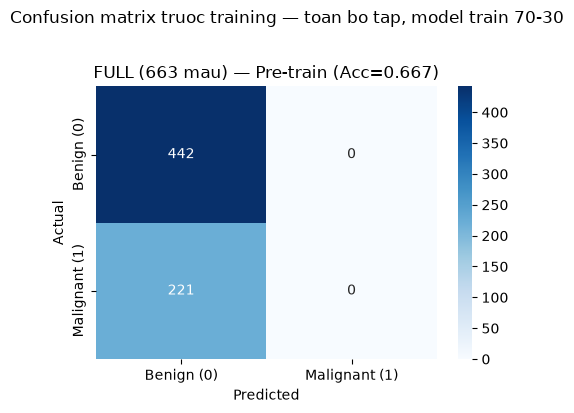

In [40]:
# 5) Confusion matrix heatmap (toan bo 663 mau, pre-train)

y_true = pretrain_results["FULL"]["y_true"]
y_pred = pretrain_results["FULL"]["y_pred"]
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", ax=ax,
    xticklabels=["Benign (0)", "Malignant (1)"],
    yticklabels=["Benign (0)", "Malignant (1)"],
)
acc = accuracy_score(y_true, y_pred)
ax.set_title(f"FULL (663 mau) — Pre-train (Acc={acc:.3f})")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.suptitle(f"Confusion matrix truoc training — toan bo tap, model train {SPLIT_LABEL}", y=1.02)
plt.tight_layout()
plt.show()

In [41]:
# 6) Phan tich mau du doan sai (toan bo 663 mau)

y_true_f = pretrain_results["FULL"]["y_true"]
y_pred_f = pretrain_results["FULL"]["y_pred"]
y_score_f = pretrain_results["FULL"]["y_score"]

wrong_mask = y_true_f != y_pred_f
wrong_df = pd.DataFrame({
    "sample_code_number": df_663["sample_code_number"].values[wrong_mask],
    "paper_split": paper_split[wrong_mask],
    "y_true": y_true_f[wrong_mask],
    "y_pred": y_pred_f[wrong_mask],
    "score": np.round(y_score_f[wrong_mask], 4),
    "clump_thickness": X_663[wrong_mask, 0],
    "uniformity_of_cell_size": X_663[wrong_mask, 1],
    "uniformity_of_cell_shape": X_663[wrong_mask, 2],
})

print(f"Full set: {wrong_mask.sum()} mau du doan sai / {len(y_true_f)}")
if len(wrong_df):
    display(wrong_df.head(15))
else:
    print("Khong co mau sai.")

Full set: 221 mau du doan sai / 663


,sample_code_number,paper_split,y_true,y_pred,score,clump_thickness,uniformity_of_cell_size,uniformity_of_cell_shape
0,1017122,TEST,1,0,0.0,1.317772,2.437174,2.482365
1,1041801,TEST,1,0,0.0,0.236787,0.011983,-0.011249
2,1044572,TRAIN,1,0,0.0,1.317772,1.397806,0.701212
3,1047630,TEST,1,0,0.0,0.957444,0.358439,1.057442
4,1050670,TRAIN,1,0,0.0,2.038428,1.397806,1.413673
5,1054590,TRAIN,1,0,0.0,0.957444,0.011983,-0.367480
6,1054593,TRAIN,1,0,0.0,2.038428,0.704894,0.701212
7,1065726,TRAIN,1,0,0.0,0.236787,-0.334473,-0.011249
8,1072179,TRAIN,1,0,0.0,2.038428,1.397806,1.413673
9,1080185,TEST,1,0,0.0,2.038428,2.437174,2.482365


In [42]:
# 7) So sanh PRE-TRAIN vs POST-TRAIN (predict toan bo 663 mau)

models_dir = Path("models")
split_slug = SPLIT_LABEL.replace("-", "_")
trained_model_path = models_dir / f"{COMPARE_STAMP}_{RUN_TAG}_{split_slug}_best_model.pkl"
metrics_ref_path = models_dir / f"{COMPARE_STAMP}_{RUN_TAG}_{split_slug}_metrics.json"

comparison_rows = []
posttrain_metrics = []

if trained_model_path.exists():
    post_model, _, _, _ = build_fs_and_model(X_train)
    post_model.load(str(trained_model_path))
    post_model.eval()
    post_model.is_training = False
    print(f"Da load model da train: {trained_model_path.name}")

    for name, (X_split, y_split) in splits.items():
        y_score_post = predict_continuous(post_model, X_split)
        y_pred_post = predict_binary(post_model, X_split)
        post_metrics = evaluate_split(
            name, y_split.astype(int), y_pred_post, y_score_post, phase="post_train"
        )
        posttrain_metrics.append(post_metrics)

        pre_row = next(r for r in pretrain_metrics if r["split"] == name)
        comparison_rows.append({
            "split": name,
            "pre_train_accuracy": pre_row["accuracy"],
            "post_train_accuracy": post_metrics["accuracy"],
            "delta_accuracy": post_metrics["accuracy"] - pre_row["accuracy"],
            "pre_train_f1": pre_row["f1_score"],
            "post_train_f1": post_metrics["f1_score"],
            "delta_f1": post_metrics["f1_score"] - pre_row["f1_score"],
        })

    comparison_df = pd.DataFrame(comparison_rows)
    print(f"\n--- So sanh Pre-train vs Post-train (FULL 663 mau, model train {SPLIT_LABEL}) ---")
    display(comparison_df)

    if metrics_ref_path.exists():
        with open(metrics_ref_path, encoding="utf-8") as f:
            ref = json.load(f)
        ref_train = ref["metrics"]["TRAIN"]
        ref_test = ref["metrics"]["TEST"]
        ref_full_correct = (
            ref_train["tn"] + ref_train["tp"] + ref_test["tn"] + ref_test["tp"]
        )
        ref_full_acc = ref_full_correct / len(X_663)
        our_full_acc = next(r["post_train_accuracy"] for r in comparison_rows if r["split"] == "FULL")
        print(
            f"\nDoi chieu metrics da luu: FULL accuracy = {ref_full_acc:.4f} (file train+test) "
            f"vs {our_full_acc:.4f} (notebook)"
        )
else:
    print(f"Khong tim thay model da train: {trained_model_path}")
    print("Bo qua buoc so sanh post-train.")

 * Detected Sugeno model type
Da load model da train: 20260628_172814_gridsearch_pca_feature_select_70_30_best_model.pkl

FULL — POST-TRAIN
- Accuracy : 0.9593
- Precision: 0.945
- Recall   : 0.9321
- F1-score : 0.9385
- ROC-AUC  : 0.9809
- Confusion matrix:
 [[430  12]
 [ 15 206]]

--- So sanh Pre-train vs Post-train (FULL 663 mau, model train 70-30) ---


,split,pre_train_accuracy,post_train_accuracy,delta_accuracy,pre_train_f1,post_train_f1,delta_f1
0,FULL,0.666667,0.959276,0.292609,0.0,0.938497,0.938497



Doi chieu metrics da luu: FULL accuracy = 0.9593 (file train+test) vs 0.9593 (notebook)


In [43]:
# 8) Export ket qua baseline

stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = Path("models")
out_dir.mkdir(exist_ok=True)

metrics_path = out_dir / f"{stamp}_pretrain_baseline_metrics.json"
metrics_csv_path = out_dir / f"{stamp}_pretrain_baseline_metrics.csv"
pred_csv_path = out_dir / f"{stamp}_pretrain_baseline_predictions.csv"

export_payload = {
    "created_at": stamp,
    "dataset": "UCI WBCD original",
    "phase": "pre_post_compare",
    "zerotype": False,
    "eval_scope": "full_663",
    "train_split_label": SPLIT_LABEL,
    "compare_stamp": COMPARE_STAMP,
    "selected_features": selected_feature_names,
    "num_rules": len(GRID_RULES),
    "pre_train": {m["split"]: m for m in pretrain_metrics},
    "post_train": {m["split"]: m for m in posttrain_metrics} if posttrain_metrics else None,
    "comparison": comparison_rows if comparison_rows else None,
}

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(export_payload, f, indent=2, ensure_ascii=False)

pretrain_metrics_df.to_csv(metrics_csv_path, index=False)

res = pretrain_results["FULL"]
pred_rows = []
for j in range(len(X_663)):
    pred_rows.append({
        "sample_code_number": int(df_663.iloc[j]["sample_code_number"]),
        "paper_split": paper_split[j],
        "eval_scope": "FULL",
        "phase": "pre_train",
        "y_true": int(res["y_true"][j]),
        "y_pred": int(res["y_pred"][j]),
        "score": float(res["y_score"][j]),
    })

pred_df = pd.DataFrame(pred_rows)
pred_df.to_csv(pred_csv_path, index=False)

print("Da luu:")
print("-", metrics_path)
print("-", metrics_csv_path)
print("-", pred_csv_path)

Da luu:
- models\20260629_112153_pretrain_baseline_metrics.json
- models\20260629_112153_pretrain_baseline_metrics.csv
- models\20260629_112153_pretrain_baseline_predictions.csv
